In [ ]:
from datetime import datetime
from getpass import getpass

rdm_url = 'https://bh.rdm.yzwlab.com/'
idp_name_1 = None
idp_username_1 = None
idp_password_1 = None
default_result_path = None
close_on_fail = False
transition_timeout = 60000

tljh_url = 'http://localhost'
tljh_username = 'admin'
tljh_password = 'change-your-password'

project_name = None

binderhub_apt_package = 'sl'
binderhub_conda_package = 'awscli'
binderhub_pip_package = 'papermill'
binderhub_r_package = 'eegkit'
binderhub_post_build_script = '''#!/bin/bash
date > ~/uptime'''
binderhub_binder_files = ['apt.txt', 'environment.yml', 'install.R', 'postBuild']
binderhub_launch_timeout = 1800000  # 30 minutes


In [2]:
if idp_username_1 is None:
    idp_username_1 = input(prompt=f'Username for {idp_name_1}')
if idp_password_1 is None:
    idp_password_1 = getpass(prompt=f'Password for {idp_username_1}@{idp_name_1}')
if tljh_username is None:
    tljh_username = input('TLJH username')
if tljh_password is None:
    tljh_password = getpass(prompt=f'Password for {tljh_username}@TLJH')
if project_name is None:
    project_name = datetime.now().strftime('TEST-BINDERHUB-%Y%m%d%H%M')

binderhub_url = tljh_url
project_url = None
project_created = False


# BinderHubアドオン repo2docker による解析環境の起動

- サブシステム名: アドオン
- ページ/アドオン: BinderHub
- 機能分類: アドオン操作
- シナリオ名: repo2docker基本イメージを使った解析環境の起動
- 用意するテストデータ: URL一覧、アカウント(既存ユーザー1: GRDM, BinderHub, GRDMは全てプロフィールを埋めていること / JupyterHubはサーバーが5つ以内の状態であること)、BinderHub OAuthクライアント情報
- 事前条件: 「プロジェクトに対するBinderHubアドオンの登録」を実施済みであること


In [3]:
import tempfile

work_dir = tempfile.mkdtemp()
if default_result_path is None:
    default_result_path = work_dir
work_dir


'/var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmpgez_hpaf'

In [85]:
import importlib
import pandas as pd

import scripts.playwright
importlib.reload(scripts.playwright)

from scripts.playwright import *
from scripts import grdm

await init_pw_context(close_on_fail=close_on_fail, last_path=default_result_path)


('20251203-121901',
 '/var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmp0o2rnji9')

In [ ]:
import asyncio

async def run_lab_command(page, command, expected_substring):
    editor = page.locator('div.jp-CodeCell div.cm-content').first
    await expect(editor).to_be_visible(timeout=transition_timeout)
    await editor.click()
    await editor.fill(command)

    run_button = page.locator('//jp-button[@data-command = "notebook:run-cell-and-select-next"]')
    await expect(run_button).to_be_visible(timeout=transition_timeout)
    await run_button.click()

    output = page.locator(f'//*[contains(@class, "jp-OutputArea")]//*[text()[contains(., "{expected_substring}")]]')
    await expect(output).to_be_visible(timeout=transition_timeout)


## ウェブブラウザの新規プライベートウィンドウでGRDMトップページを表示する

GRDMトップページが表示されること

Start epoch: 1764731941.619589 seconds


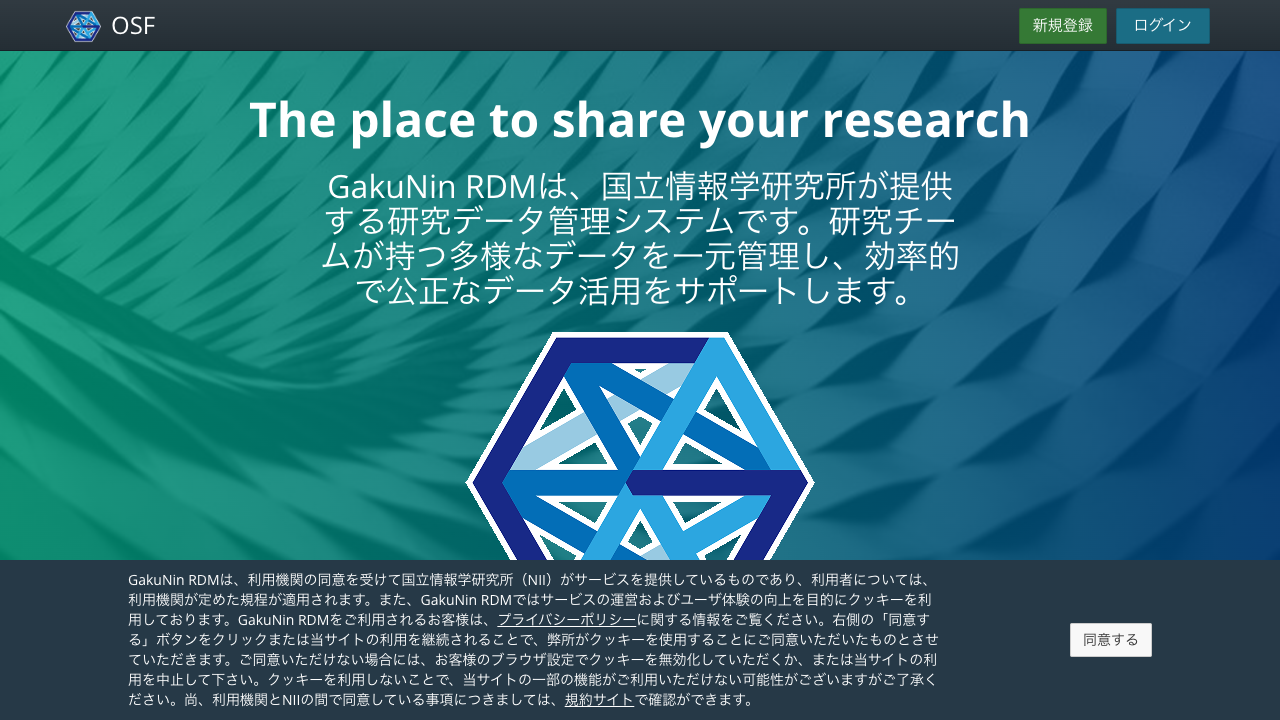

In [87]:
async def _step(page):
    await page.goto(rdm_url)
    consent_button = page.locator('//button[text() = "同意する"]')
    if await consent_button.count():
        await consent_button.click()
    await expect(page.locator('//button[text() = "ログイン"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)


## IdPを利用し、既存ユーザー1としてログインする

GRDMダッシュボードが表示されること

Start epoch: 1764731943.8219829 seconds


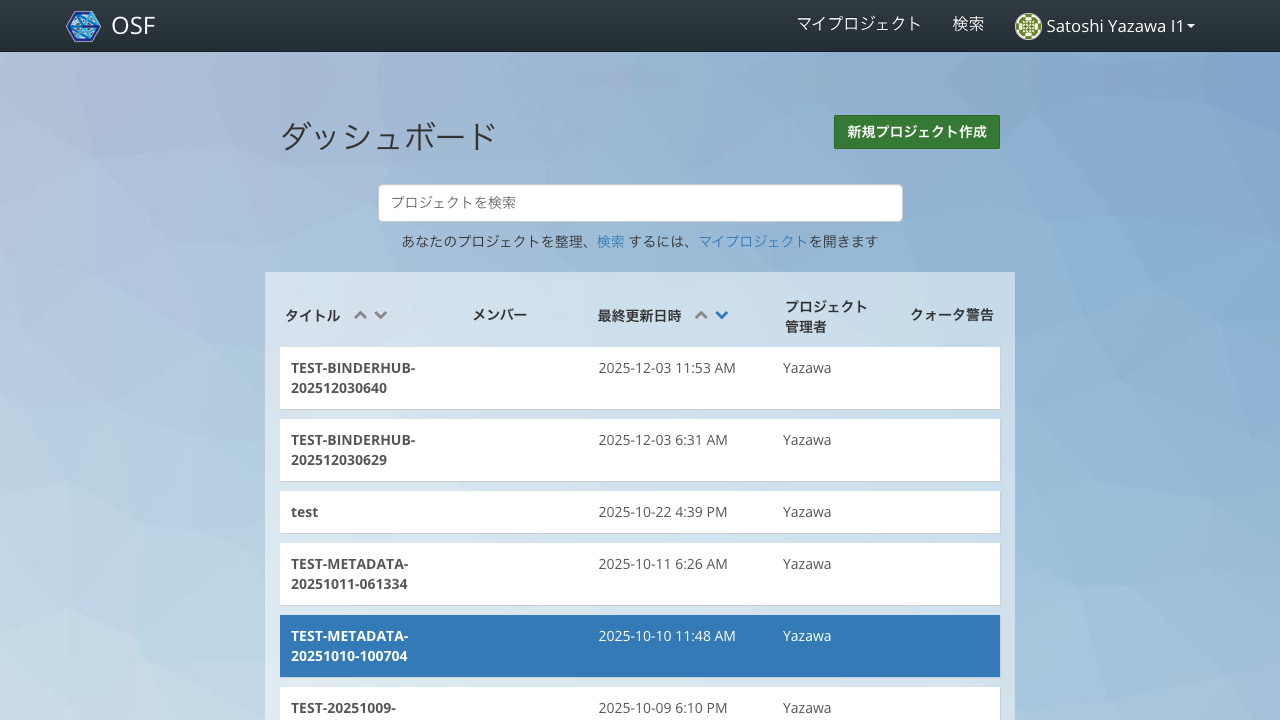

In [88]:
async def _step(page):
    await grdm.login(page, idp_name_1, idp_username_1, idp_password_1, transition_timeout=transition_timeout)
    await grdm.expect_dashboard(page, transition_timeout=transition_timeout)

await run_pw(_step)


## ダッシュボードから「新規プロジェクト作成」をクリックする

指定したプロジェクトが存在しない場合、新規プロジェクトが作成されること

Start epoch: 1764731947.807009 seconds
Project already exists: TEST-BINDERHUB-202512030640


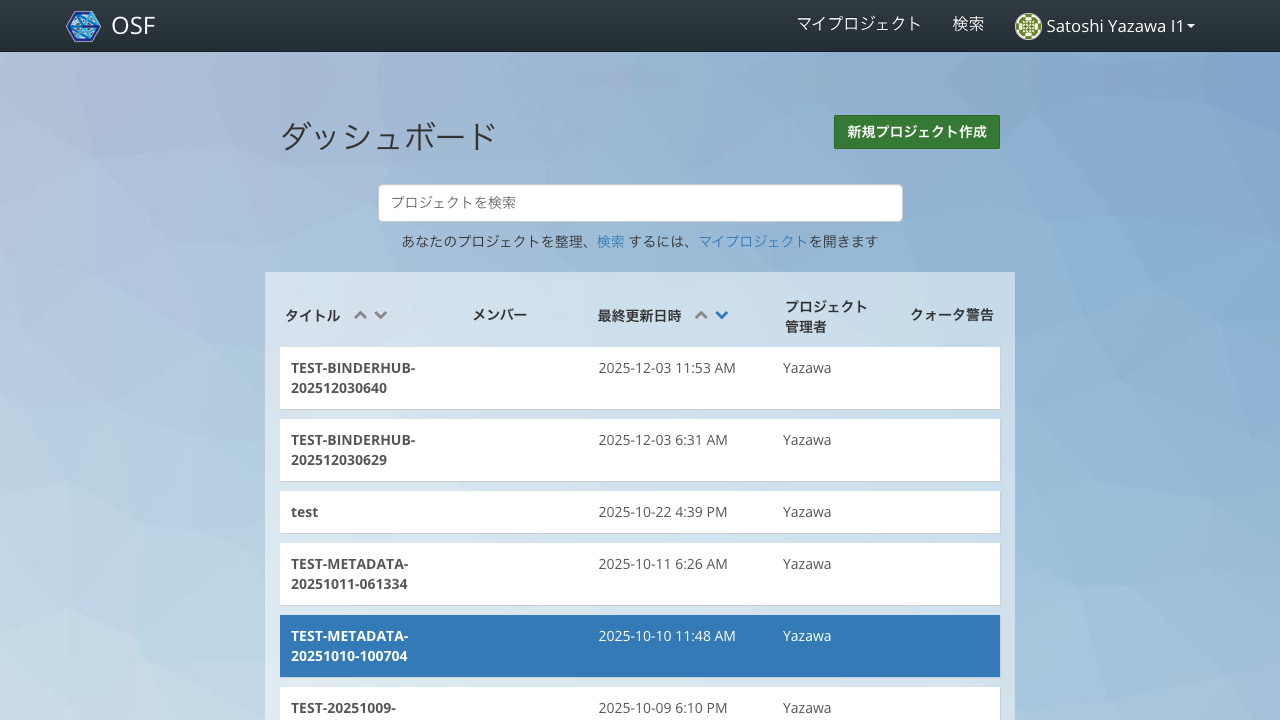

In [89]:
async def _step(page):
    global project_created
    project_created = await grdm.ensure_project_exists(page, project_name, transition_timeout=transition_timeout)
    if project_created:
        print(f'Created project: {project_name}')
    else:
        print(f'Project already exists: {project_name}')

await run_pw(_step)


## ダッシュボードのプロジェクト一覧から作成したプロジェクトをクリックする

プロジェクトダッシュボードが表示されること

Start epoch: 1764731947.940001 seconds


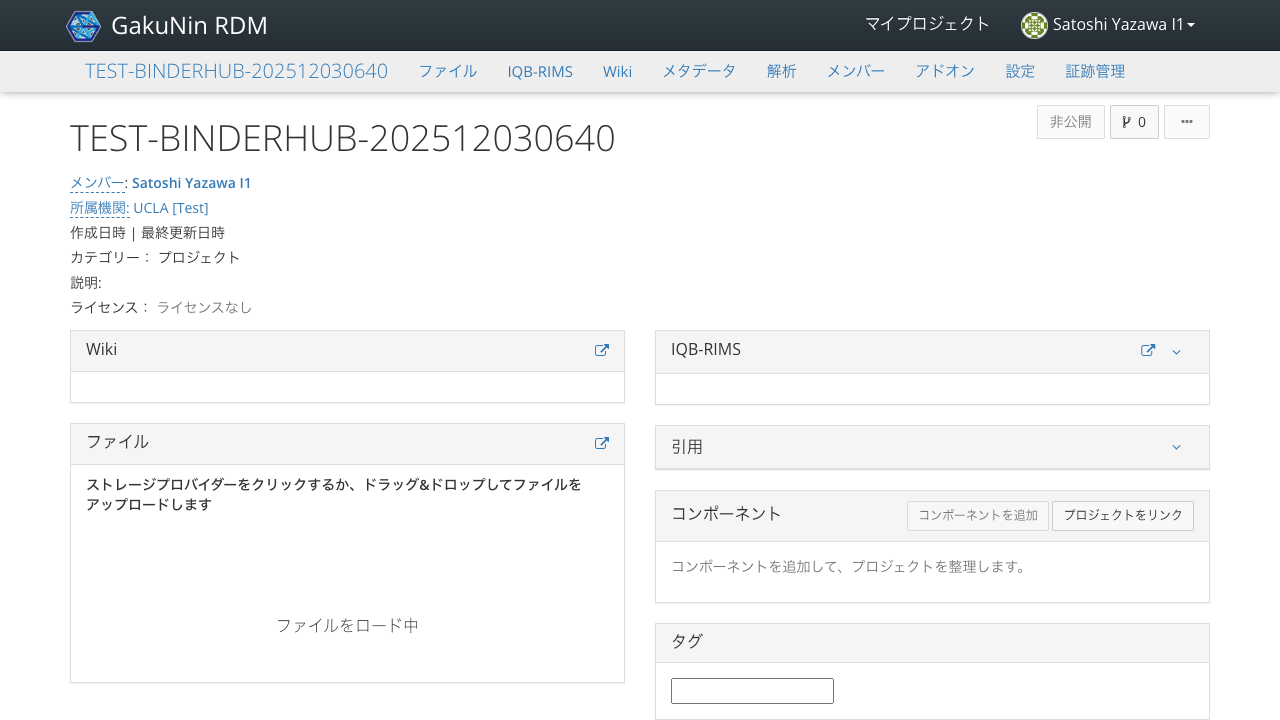

In [90]:
async def _step(page):
    global project_url
    await page.locator(f'//*[@data-test-dashboard-item-title and text() = "{project_name}"]').click()
    await expect(page.locator('//span[@id = "nodeTitleEditable"]')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator('//a[text() = "アドオン"]')).to_be_visible(timeout=transition_timeout)
    project_url = page.url

await run_pw(_step)


## プロジェクトダッシュボードの上部メニューから「解析」をクリックする

BinderHubアドオンページが表示されること

Start epoch: 1764731949.2012749 seconds


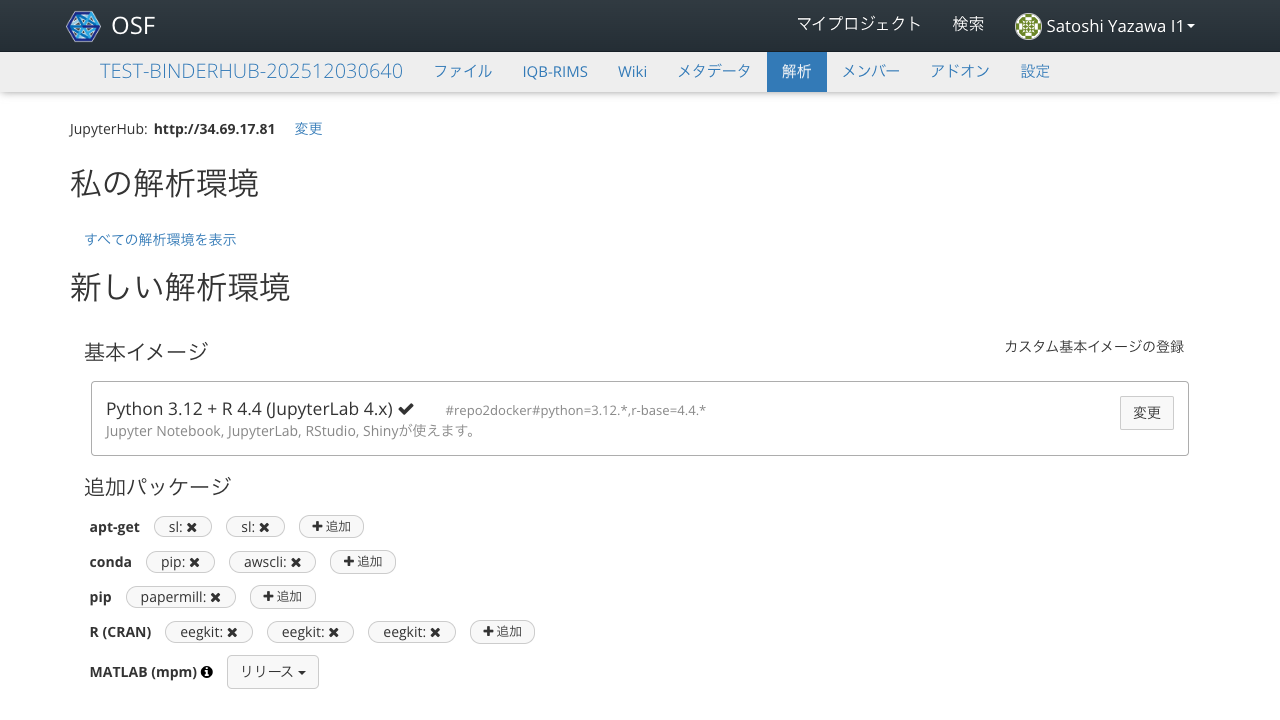

In [91]:
async def _step(page):
    await page.locator('//a[contains(text(), "解析")]').click()
    await expect(page.locator('//*[@data-test-binderhub-launch]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)


## 「apt-get」の「+追加」をクリックし、パッケージを登録する

パッケージ名がaptに表示されること

In [92]:
async def _step(page):
    await page.locator('//div[@data-test-package-editor = "apt"]//*[@data-test-package-add]').click()
    field = page.locator('//input[@name = "package_name"]')
    await expect(field).to_be_visible(timeout=transition_timeout)
    await field.fill(binderhub_apt_package)
    await page.locator('//button[@data-test-package-item-confirm]').click()
    await expect(page.locator(f'//div[@data-test-package-editor = "apt"]//*[text() = "{binderhub_apt_package}"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)


Start epoch: 1764731954.482474 seconds
Screenshot: /var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmpgez_hpaf/last-screenshot.png


Error: LocatorAssertions.to_be_visible: Error: strict mode violation: locator("//div[@data-test-package-editor = \"apt\"]//*[text() = \"sl\"]") resolved to 2 elements:
    1) <button data-ember-action="" data-ember-action-88="88" data-test-package-edit-item="0">↵                        sl:↵                    </button> aka get_by_role("button", name="sl:").first
    2) <button data-ember-action="" data-ember-action-91="91" data-test-package-edit-item="1">↵                        sl:↵                    </button> aka get_by_role("button", name="sl:").nth(1)

Call log:
  - LocatorAssertions.to_be_visible with timeout 60000ms
  -   - waiting for locator("//div[@data-test-package-editor = \"apt\"]//*[text() = \"sl\"]")


## 「conda」の「+追加」をクリックし、パッケージを登録する

パッケージ名がcondaに表示されること

Start epoch: 1764730404.265418 seconds


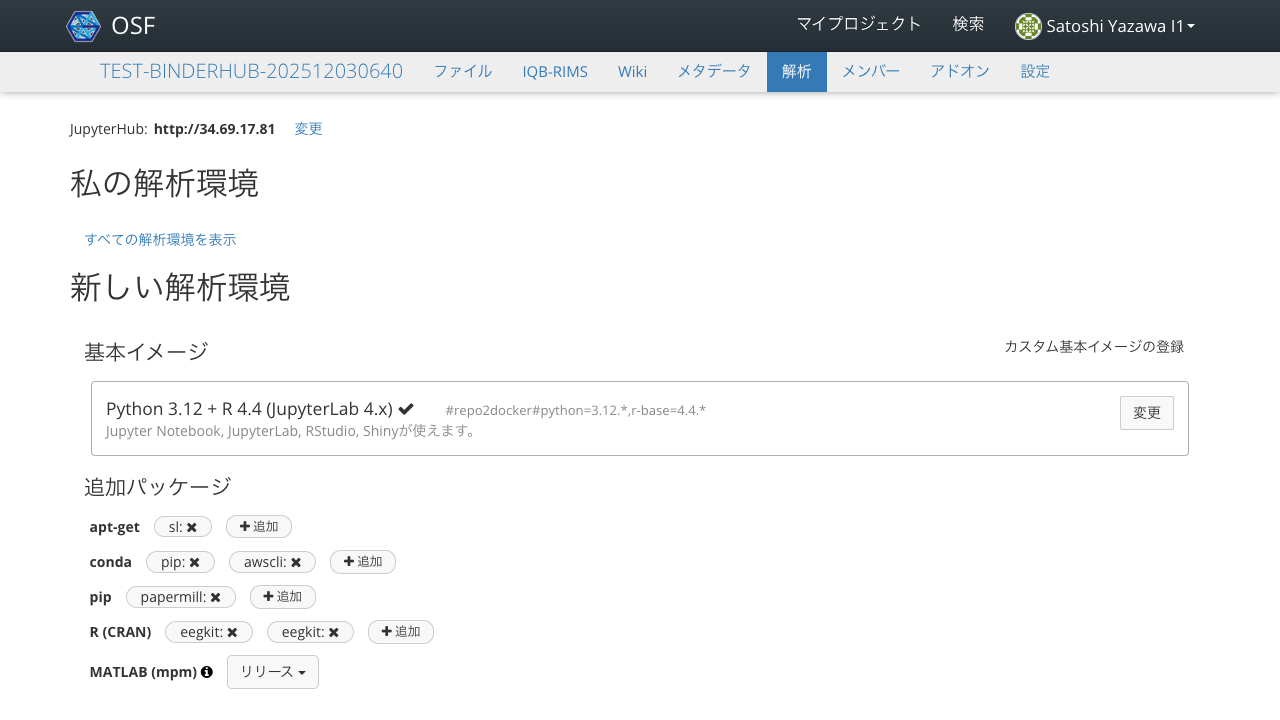

In [ ]:
async def _step(page):
    await page.locator('//div[@data-test-package-editor = "conda"]//*[@data-test-package-add]').click()
    field = page.locator('//input[@name = "package_name"]')
    await expect(field).to_be_visible(timeout=transition_timeout)
    await field.fill(binderhub_conda_package)
    await page.locator('//button[@data-test-package-item-confirm]').click()
    await expect(page.locator(f'//div[@data-test-package-editor = "conda"]//*[text() = "{binderhub_conda_package}"]')).to_be_visible(timeout=transition_timeout)
    await page.wait_for_load_state('networkidle')

await run_pw(_step)


## 「pip」の「+追加」をクリックし、パッケージを登録する

パッケージ名がpipに表示されること

Start epoch: 1764730404.413881 seconds


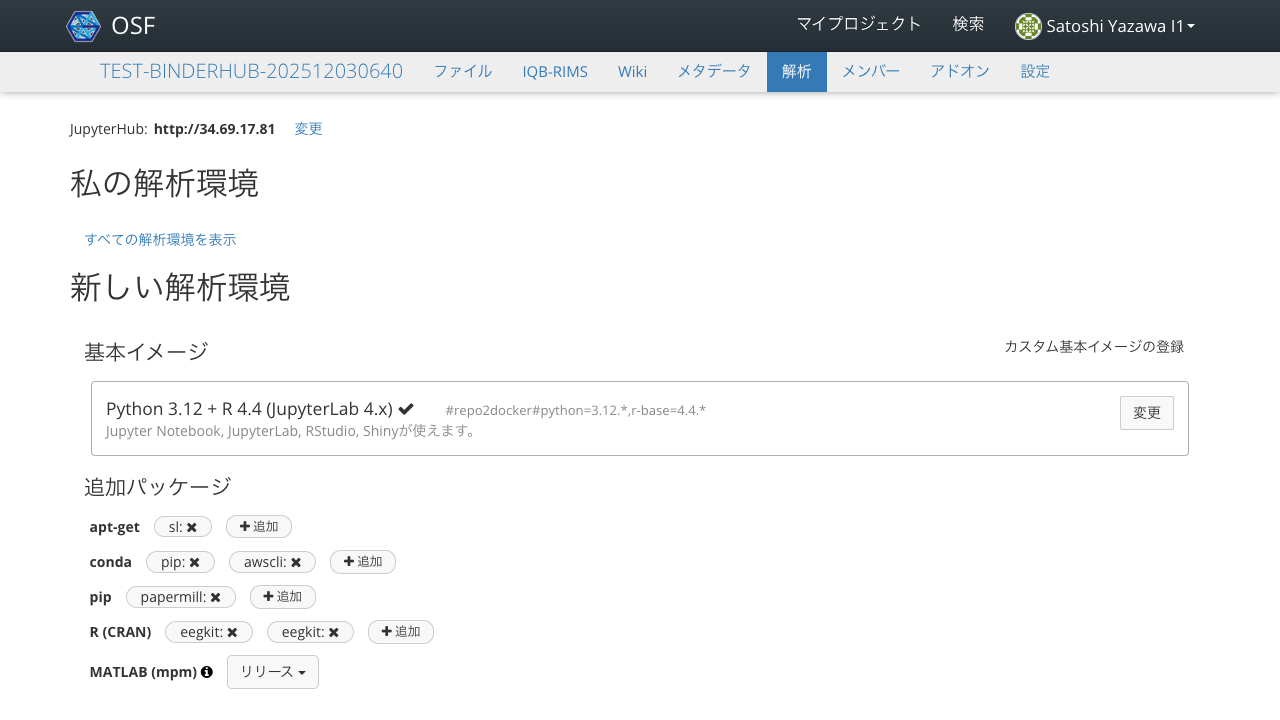

In [ ]:
async def _step(page):
    await page.locator('//div[@data-test-package-editor = "pip"]//*[@data-test-package-add]').click()
    field = page.locator('//input[@name = "package_name"]')
    await expect(field).to_be_visible(timeout=transition_timeout)
    await field.fill(binderhub_pip_package)
    await page.locator('//button[@data-test-package-item-confirm]').click()
    await expect(page.locator(f'//div[@data-test-package-editor = "pip"]//*[text() = "{binderhub_pip_package}"]')).to_be_visible(timeout=transition_timeout)
    await page.wait_for_load_state('networkidle')

await run_pw(_step)


## 「R (MRAN)」の「+追加」をクリックし、パッケージを登録する

パッケージ名がR (MRAN)に表示されること

In [ ]:
async def _step(page):
    await page.locator('//div[@data-test-package-editor = "rmran"]//*[@data-test-package-add]').click()
    field = page.locator('//input[@name = "package_name"]')
    await expect(field).to_be_visible(timeout=transition_timeout)
    await field.fill(binderhub_r_package)
    await page.locator('//button[@data-test-package-item-confirm]').click()
    await expect(page.locator(f'//div[@data-test-package-editor = "rmran"]//*[text() = "{binderhub_r_package}"]')).to_be_visible(timeout=transition_timeout)
    await page.wait_for_load_state('networkidle')

await run_pw(_step)


Start epoch: 1764730404.563489 seconds
Screenshot: /var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmpgez_hpaf/last-screenshot.png


Error: LocatorAssertions.to_be_visible: Error: strict mode violation: locator("//div[@data-test-package-editor = \"rmran\"]//*[text() = \"eegkit\"]") resolved to 2 elements:
    1) <button data-ember-action="" data-ember-action-106="106" data-test-package-edit-item="0">↵                        eegkit:↵                …</button> aka get_by_role("button", name="eegkit:").first
    2) <button data-ember-action="" data-ember-action-109="109" data-test-package-edit-item="1">↵                        eegkit:↵                …</button> aka get_by_role("button", name="eegkit:").nth(1)

Call log:
  - LocatorAssertions.to_be_visible with timeout 60000ms
  -   - waiting for locator("//div[@data-test-package-editor = \"rmran\"]//*[text() = \"eegkit\"]")


## 「自動実行スクリプト」をクリックする

スクリプトエディタが表示されること

Start epoch: 1764729095.722454 seconds


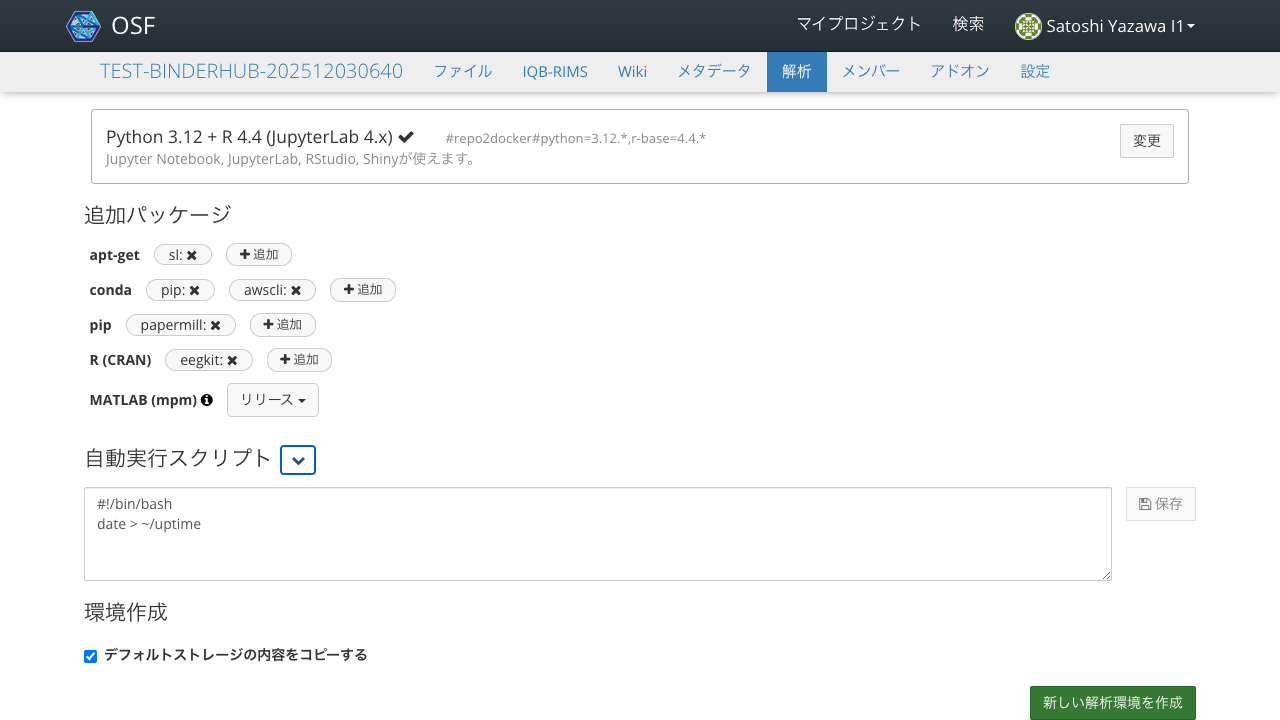

In [ ]:
async def _step(page):
    await page.locator('//h3//button/*[contains(@class, "fa-chevron-right")]').click()
    await expect(page.locator('//textarea[@data-test-post-build]')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator('//button[@data-test-save-post-build]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)


## スクリプトを入力し、保存する

保存ボタンが有効になり、保存後に無効化されること

In [ ]:
async def _step(page):
    textarea = page.locator('//textarea[@data-test-post-build]')
    await textarea.fill(binderhub_post_build_script)
    await textarea.press('Tab')
    save_button = page.locator('//button[@data-test-save-post-build]')
    await expect(save_button).to_be_enabled(timeout=transition_timeout)
    await save_button.click()
    await expect(save_button).to_be_disabled(timeout=transition_timeout)
    await page.wait_for_load_state('networkidle')
    await asyncio.sleep(10)

await run_pw(_step)


Start epoch: 1764730440.629877 seconds
Screenshot: /var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmpgez_hpaf/last-screenshot.png


TimeoutError: Locator.fill: Timeout 30000ms exceeded.
Call log:
  - waiting for locator("//textarea[@data-test-post-build]")


## プロジェクトダッシュボードの上部メニューから「ファイル」をクリックする

フォルダ「.binder」が作成されていること

Start epoch: 1764732003.8276439 seconds


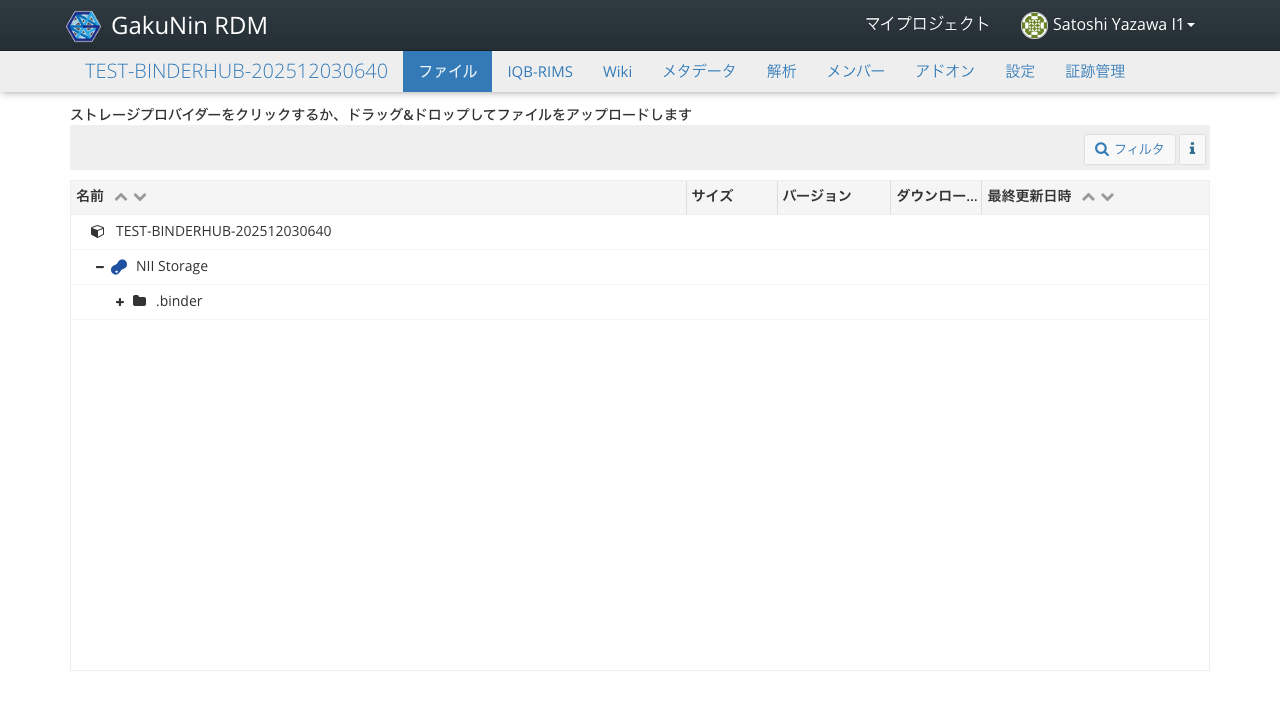

In [93]:
async def _step(page):
    await page.locator('//*[@data-test-node-navbar-link = "files"]').click()
    binder_folder = page.locator('//*[text() = ".binder"]/../..//*[contains(@class, "fa-plus")]')
    await expect(binder_folder).to_be_visible(timeout=transition_timeout)

await run_pw(_step)


## 「.binder」フォルダを開き、生成されたファイルを確認する

apt.txt などのファイルが表示されること

Start epoch: 1764732006.5943732 seconds


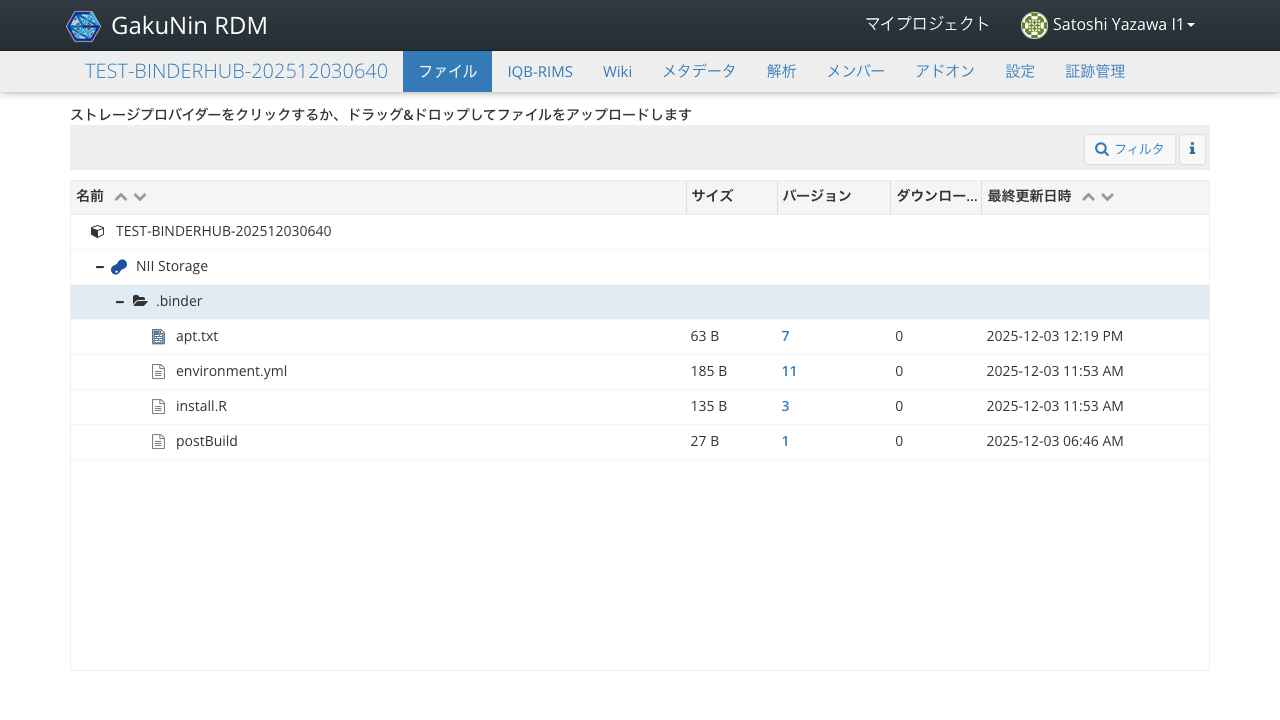

In [94]:
async def _step(page):
    toggle = page.locator('//*[text() = ".binder"]/../..//*[contains(@class, "fa-plus")]')
    await toggle.click()
    for filename in binderhub_binder_files:
        await expect(page.locator(f'//*[text() = "{filename}"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)


## プロジェクトダッシュボードの上部メニューから「解析」をクリックする

BinderHubアドオンページが表示されること

Start epoch: 1764732007.560734 seconds


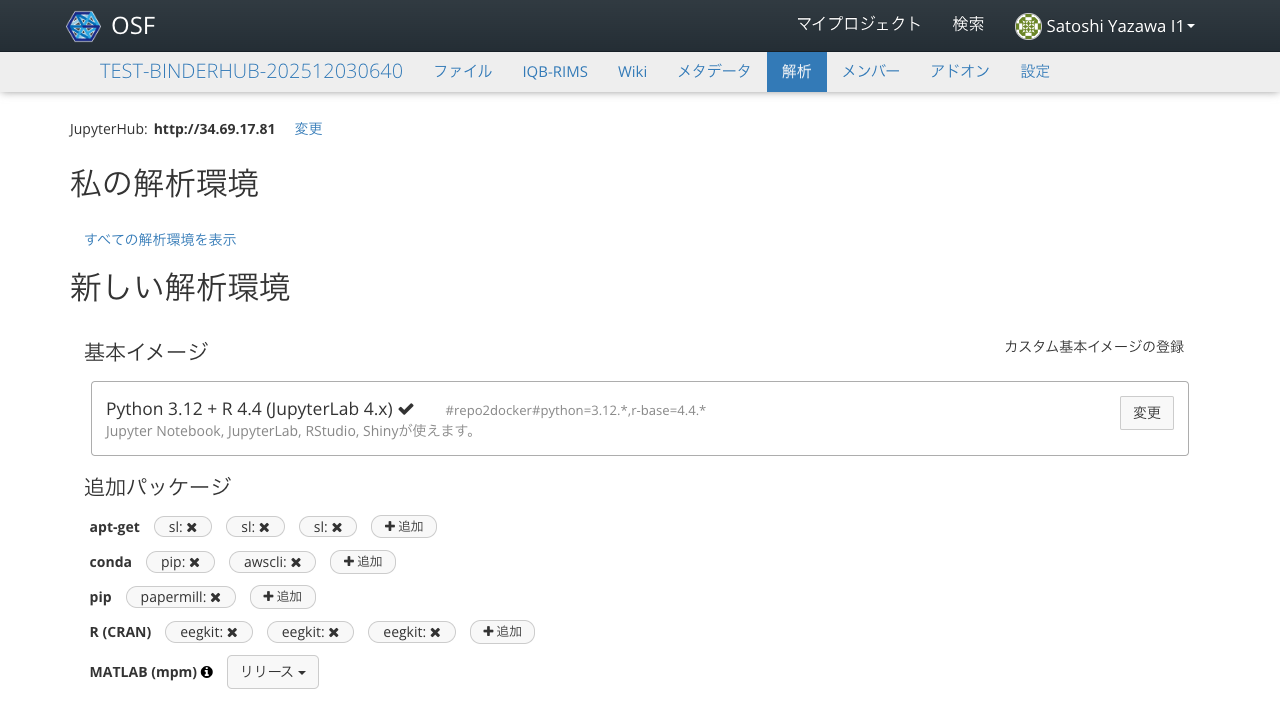

In [95]:
async def _step(page):
    await page.locator('//a[contains(text(), "解析")]').click()
    await expect(page.locator('//*[@data-test-binderhub-launch]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)


## 「新しい解析環境を作成」をクリックする

JupyterHubのログインページが表示されること

Start epoch: 1764732011.763239 seconds


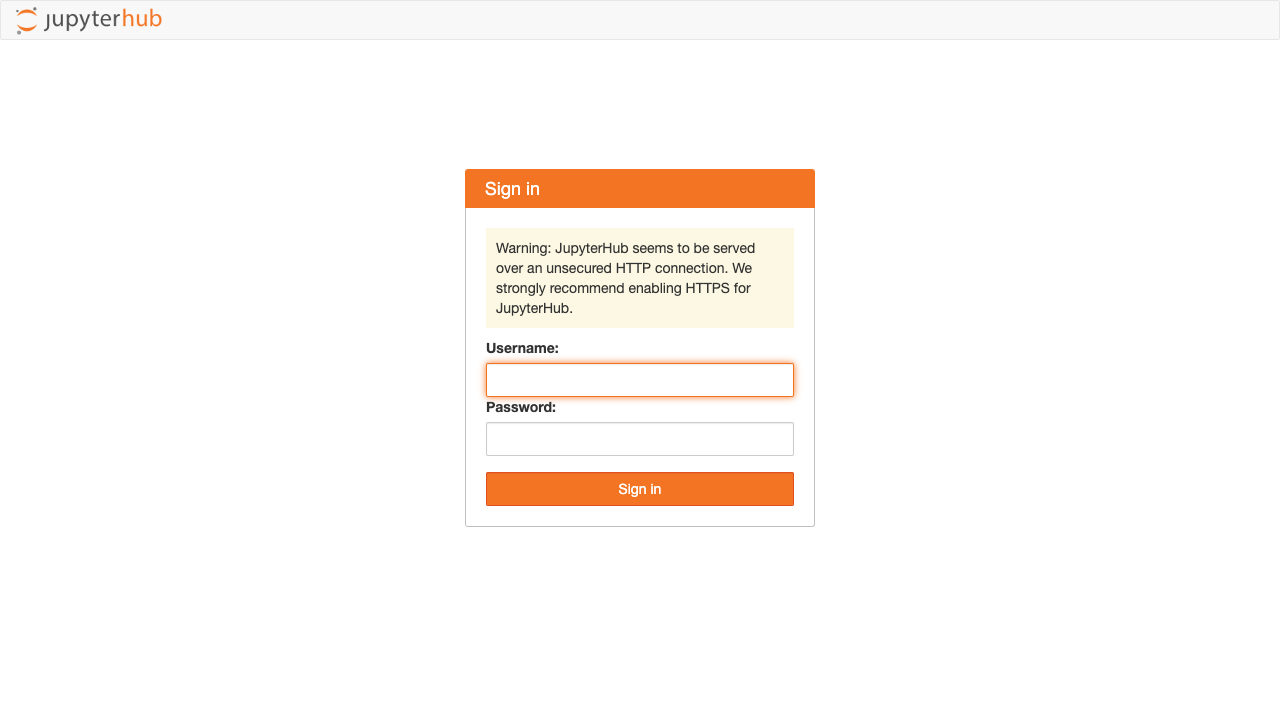

In [96]:
async def _step(page):
    popup_future = page.wait_for_event('popup', timeout=binderhub_launch_timeout)
    await page.locator('//*[@data-test-binderhub-launch]').click()
    popup = await popup_future
    await expect(popup.locator('#username_input')).to_be_visible(timeout=transition_timeout)
    return popup

await run_pw(_step)


## TLJHのユーザー名・パスワードを入力し、Sign inをクリックする

TLJHのビルド画面が表示されること

Start epoch: 1764732013.3242922 seconds
TEST-BINDERHUB-202512030640 - 2025-12-03 03:20:23


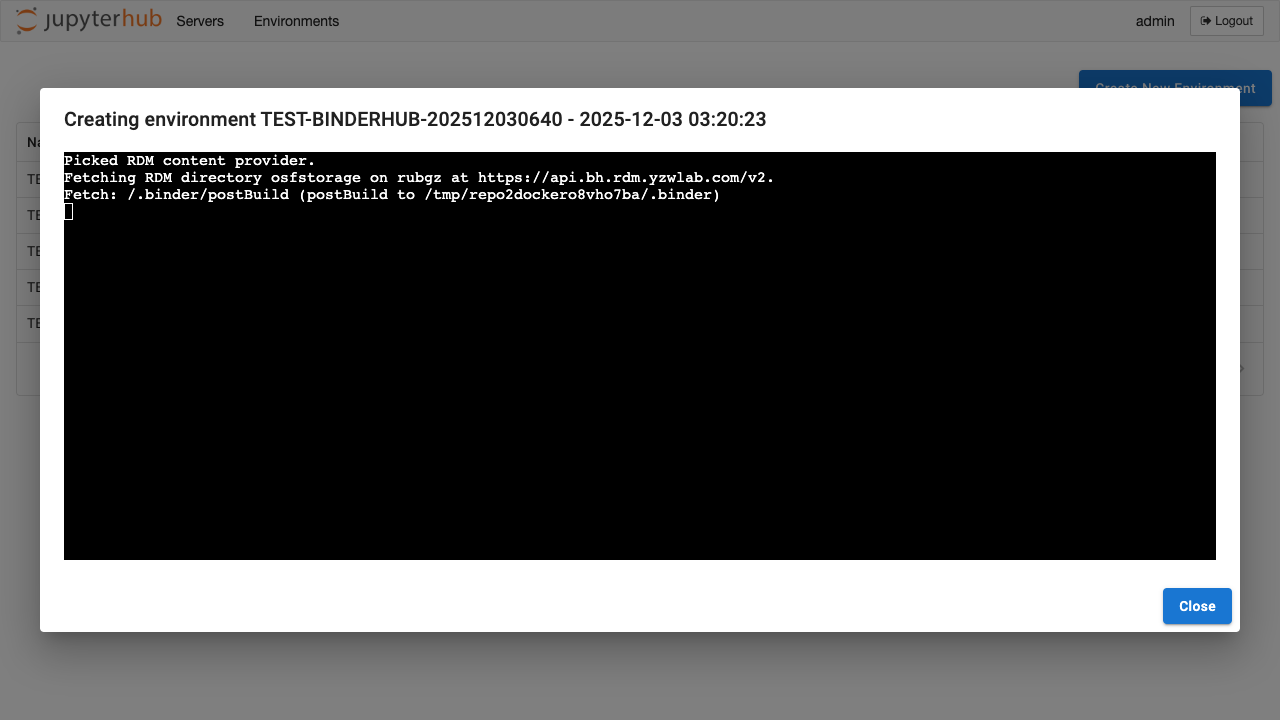

In [97]:
environment_name = None

async def _step(page):
    await page.locator('#username_input').fill(tljh_username)
    await page.locator('#password_input').fill(tljh_password)
    await page.locator('#login_submit').click()

    await expect(page.locator(f'//a[text()="{project_url}"]/../..//*[@data-testid="SyncIcon"]')).to_be_visible(timeout=transition_timeout)
    await page.locator(f'//a[text()="{project_url}"]/../..//*[@data-testid="SyncIcon"]').click()

    global environment_name
    env_locator = page.locator('//*[@data-testid="SyncIcon"]/../../..//*[@data-field="display_name"]//*[@role="presentation"]')
    environment_name = await env_locator.text_content()
    print(environment_name)
    await asyncio.sleep(3)

await run_pw(_step)


## Statusがチェックマークになるまで待つ

Start epoch: 1764732029.466203 seconds


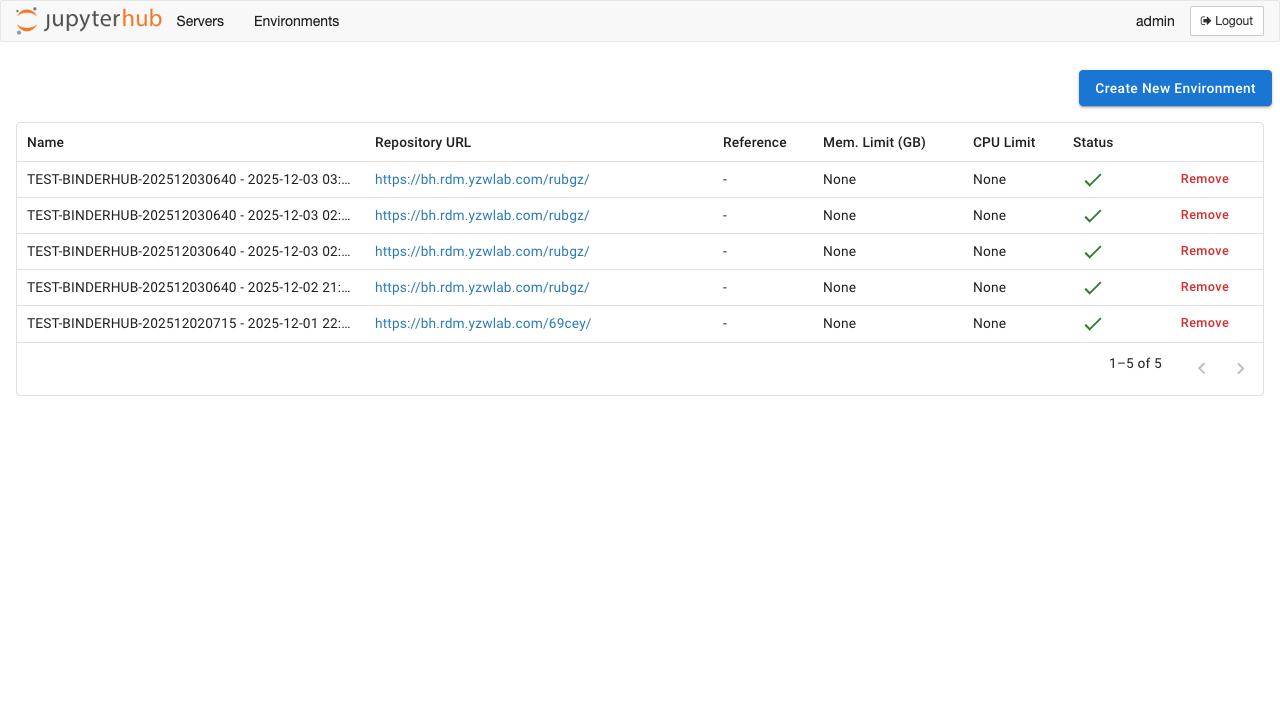

In [98]:
import traceback

async def _step(page):
    await page.locator('//*[contains(text(), "Close")]').click()
    retry_count = 20 * 3
    while retry_count > 0:
        try:
            await expect(page.locator(f'//*[@title="{environment_name}"]/../..//*[@data-testid="CheckIcon"]')).to_be_visible(timeout=transition_timeout)
            break
        except:
            retry_count -= 1
            if retry_count == 0:
                traceback.print_exc()
            await page.reload()

    try:
        await expect(page.locator(f'//*[@title="{environment_name}"]/../..//*[@data-testid="CheckIcon"]')).to_be_visible(timeout=transition_timeout)
    except:
        try:
            await page.locator(f'//*[@title="{environment_name}"]/../..//*[@data-testid="SyncIcon"]').click()
            await asyncio.sleep(30)
        except:
            traceback.print_exc()
        raise

await run_pw(_step)


## 「Servers」をクリックする

Start epoch: 1764733366.175498 seconds


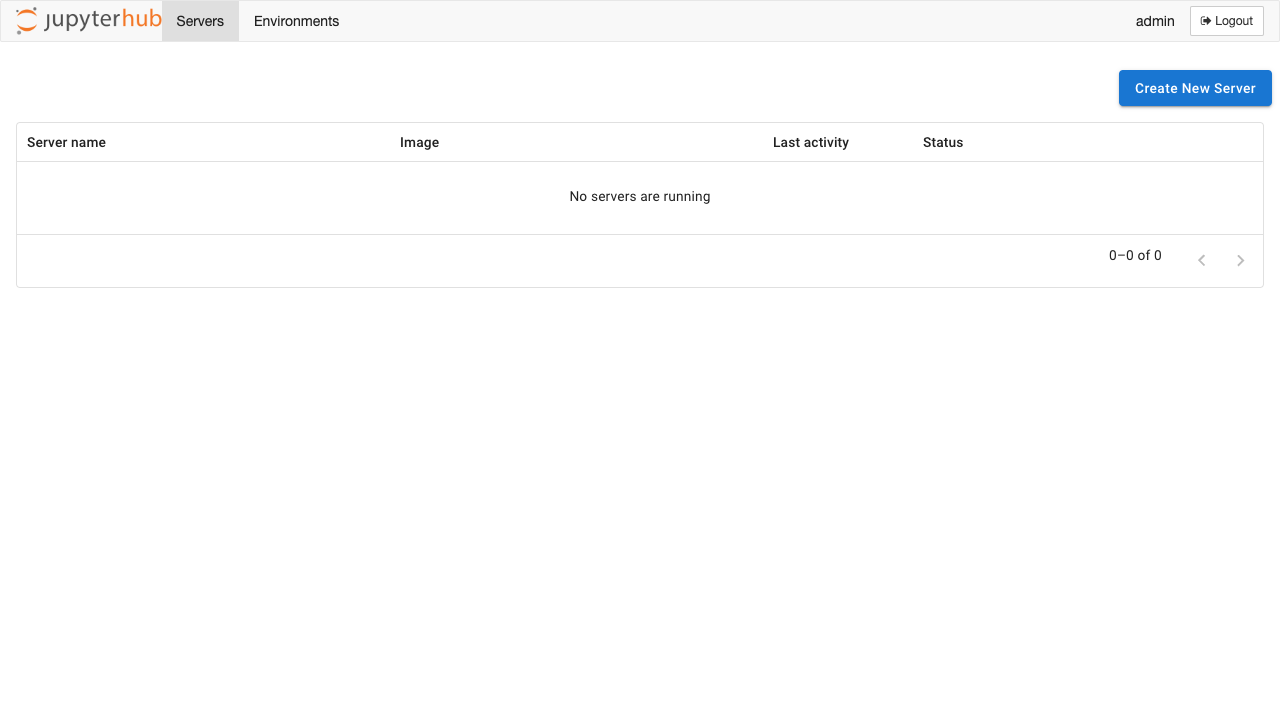

In [99]:
async def _step(page):
    #<a href="/services/tljh_repo2docker/servers">Servers</a>
    await page.locator('//a[@href="/services/tljh_repo2docker/servers"]').click()
    # <button class="MuiButtonBase-root MuiButton-root MuiButton-contained MuiButton-containedPrimary MuiButton-sizeMedium MuiButton-containedSizeMedium MuiButton-colorPrimary MuiButton-root MuiButton-contained MuiButton-containedPrimary MuiButton-sizeMedium MuiButton-containedSizeMedium MuiButton-colorPrimary css-1xscybk" tabindex="0" type="button">Create new Server<span class="MuiTouchRipple-root css-w0pj6f"></span></button>
    await expect(page.locator('//button[contains(text(), "Create new Server")]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「Create new Server」をクリックする

Start epoch: 1764733368.660953 seconds


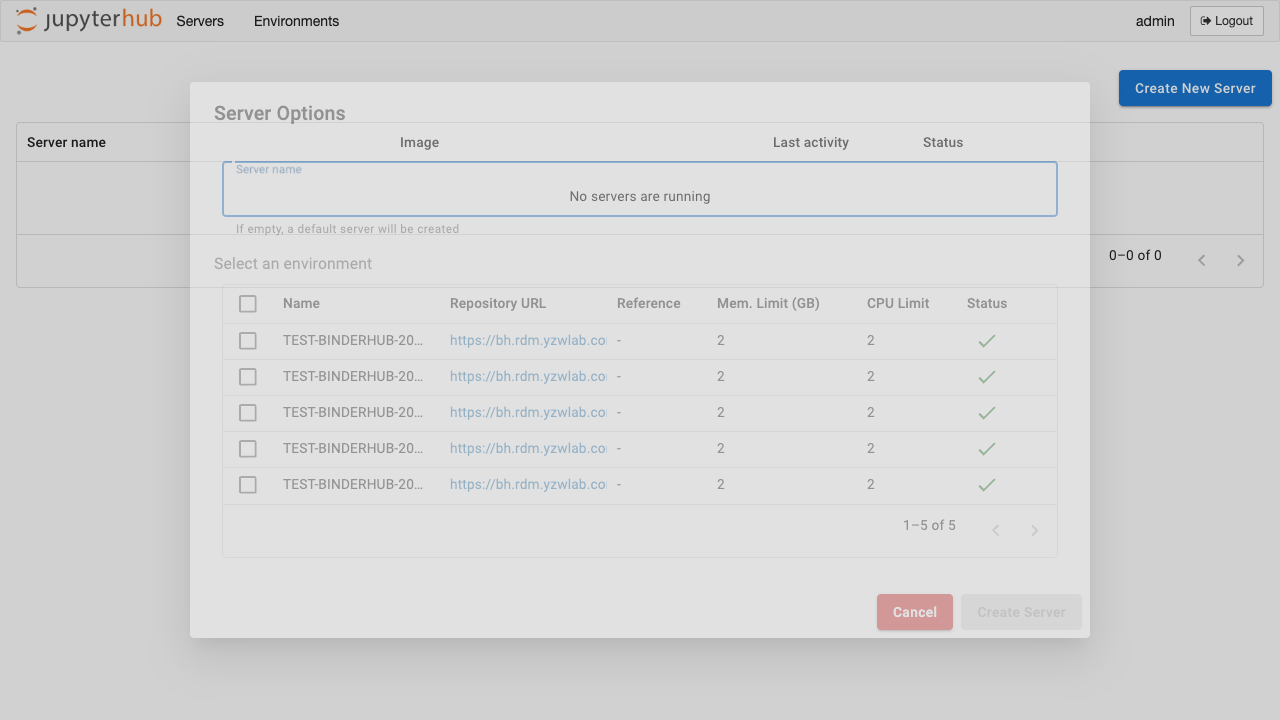

In [100]:
async def _step(page):
    await page.locator('//button[contains(text(), "Create new Server")]').click()
    await expect(page.locator(f'//*[@title="{environment_name}"]/../..//input[@type="checkbox"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## このプロジェクトURLに対応する環境のチェックボックスをクリックし、サーバー名に「test-server」と入力し、「Create Server」をクリックする

Start epoch: 1764733423.727711 seconds


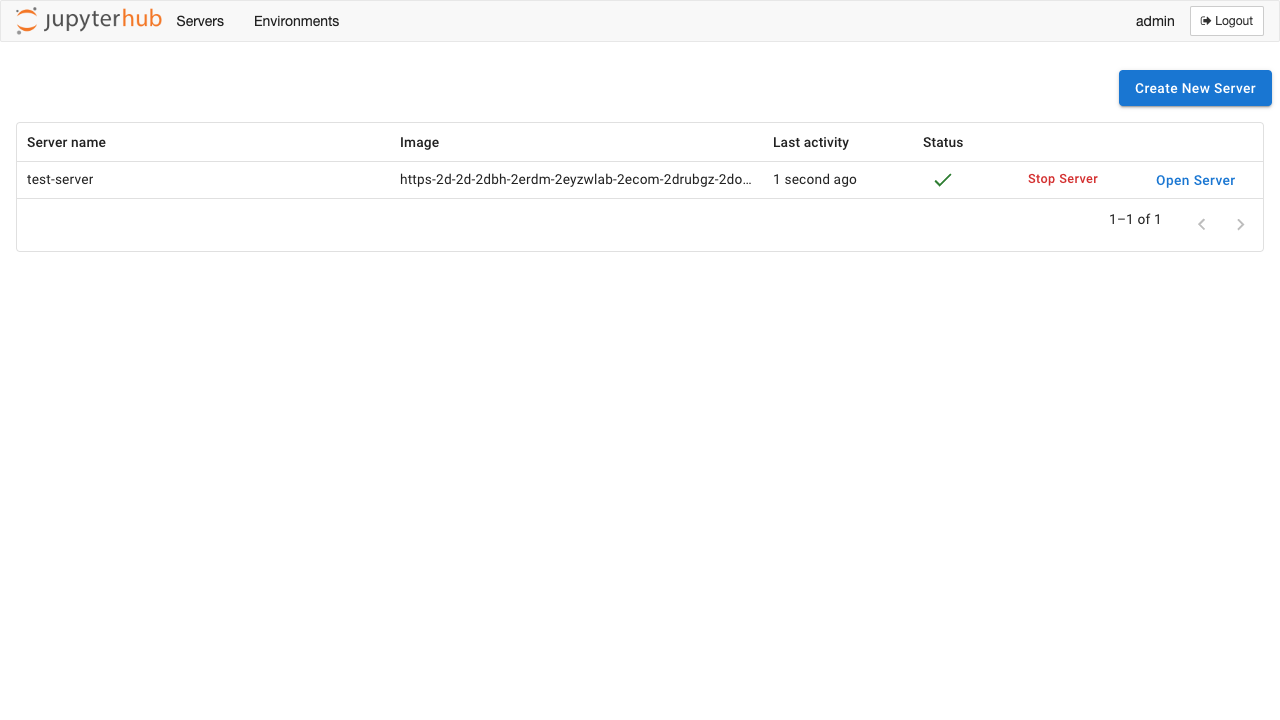

In [102]:
async def _step(page):
    await page.locator(f'//*[@title="{environment_name}"]/../..//input[@type="checkbox"]').click()
    await page.locator('#server_name').fill('test-server')
    await page.locator('//button[contains(text(), "Create Server")]').click()
    await expect(page.locator('#server_name')).not_to_be_visible(timeout=transition_timeout * 5)

await run_pw(_step)

## 「test-server」の「Open Server」をクリックする


Start epoch: 1764733436.707647 seconds


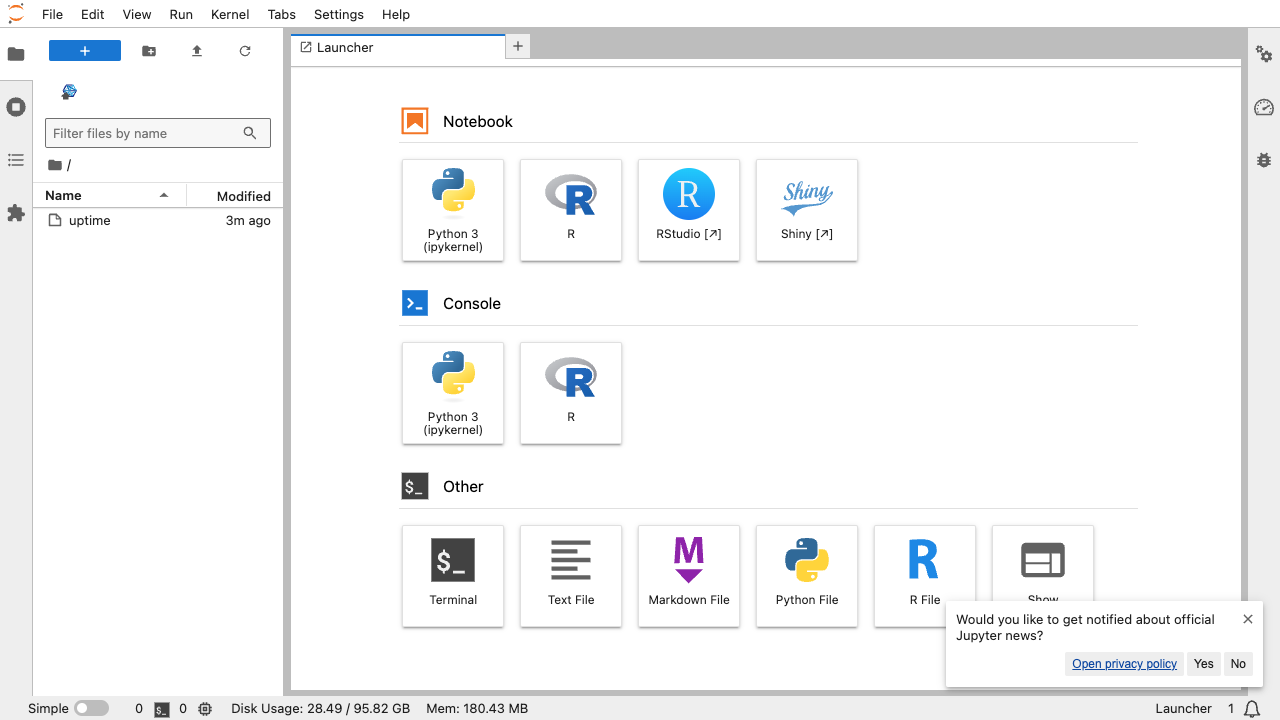

In [103]:
async def _step(page):
    popup_future = page.wait_for_event('popup')
    await page.locator('//a[contains(text(), "Open Server")]').click()
    popup = await popup_future

    #<div class="jp-LauncherCard" title="Python 3 (ipykernel)" tabindex="0" data-category="Notebook"><div class="jp-LauncherCard-icon"><img src="/user/admin/test-server/kernelspecs/python3/logo-svg.svg" class="jp-Launcher-kernelIcon" alt="Python 3 (ipykernel)"></div><div class="jp-LauncherCard-label" title="Python 3 (ipykernel)"><p>Python 3 (ipykernel)</p></div></div>
    await expect(popup.locator('//*[@class="jp-LauncherCard" and @title="Python 3 (ipykernel)" and @data-category="Notebook"]')).to_be_visible(timeout=transition_timeout)

    return popup

await run_pw(_step)

## 新規Notebookを作成する

Start epoch: 1764733453.073427 seconds


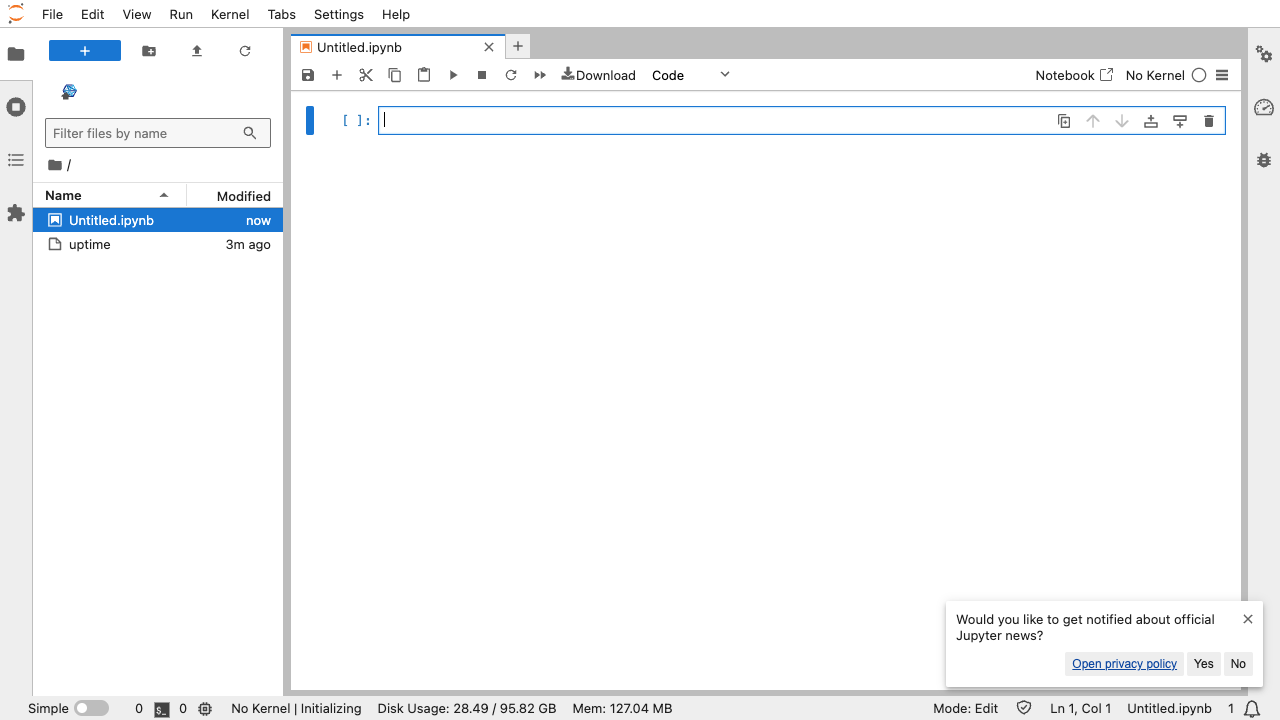

In [104]:
async def _step(page):
    launcher_label = 'Python 3 (ipykernel)'
    launcher = page.locator(f'//*[@class = "jp-LauncherCard" and @title = "{launcher_label}" and @data-category = "Notebook"]')
    await expect(launcher).to_be_visible(timeout=transition_timeout)
    await launcher.click()

    await expect(page.locator('//*[contains(@class, "jp-Notebook-ExecutionIndicator") and @data-status="idle"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「!which /usr/games/sl」を実行して結果を確認する

コマンドの出力に `/usr/games/sl` が含まれること

Start epoch: 1764733456.504454 seconds


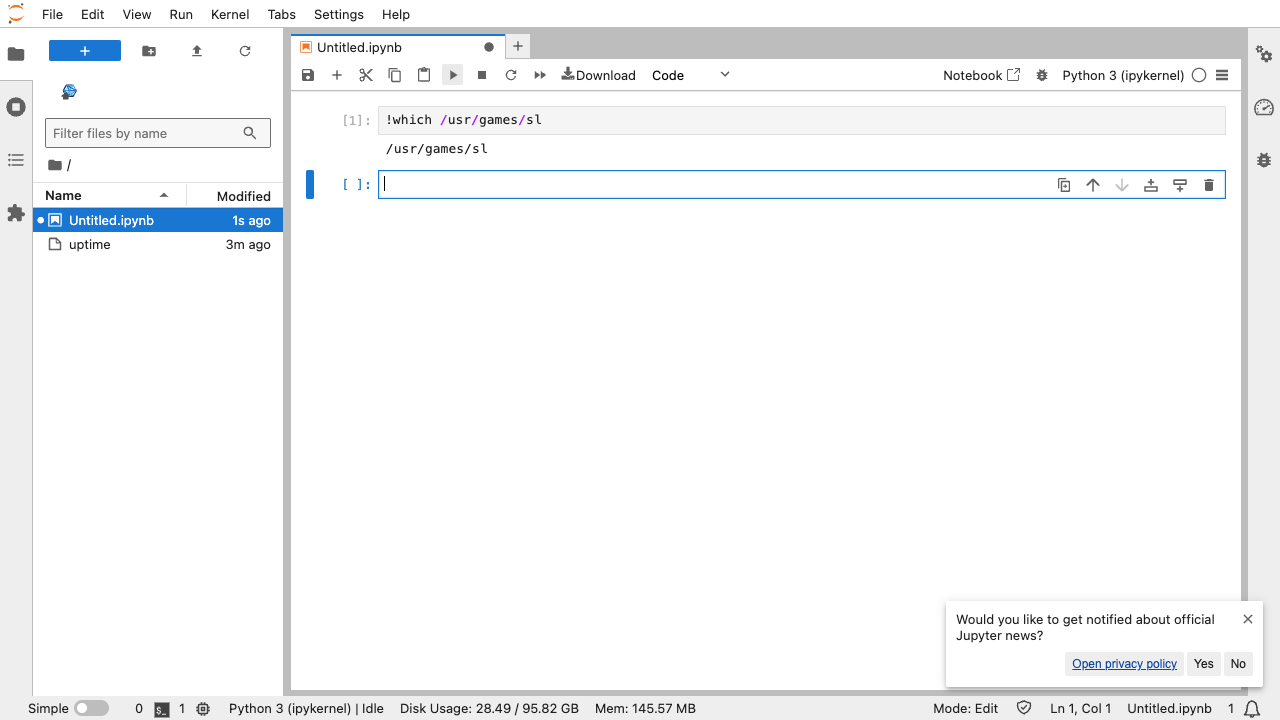

In [105]:
async def _step(page):
    await run_lab_command(page, '!which /usr/games/sl', '/usr/games/sl')

await run_pw(_step)


## 「!aws」を実行して結果を確認する

コマンドの出力に `usage: aws` が含まれること

Start epoch: 1764733460.16157 seconds


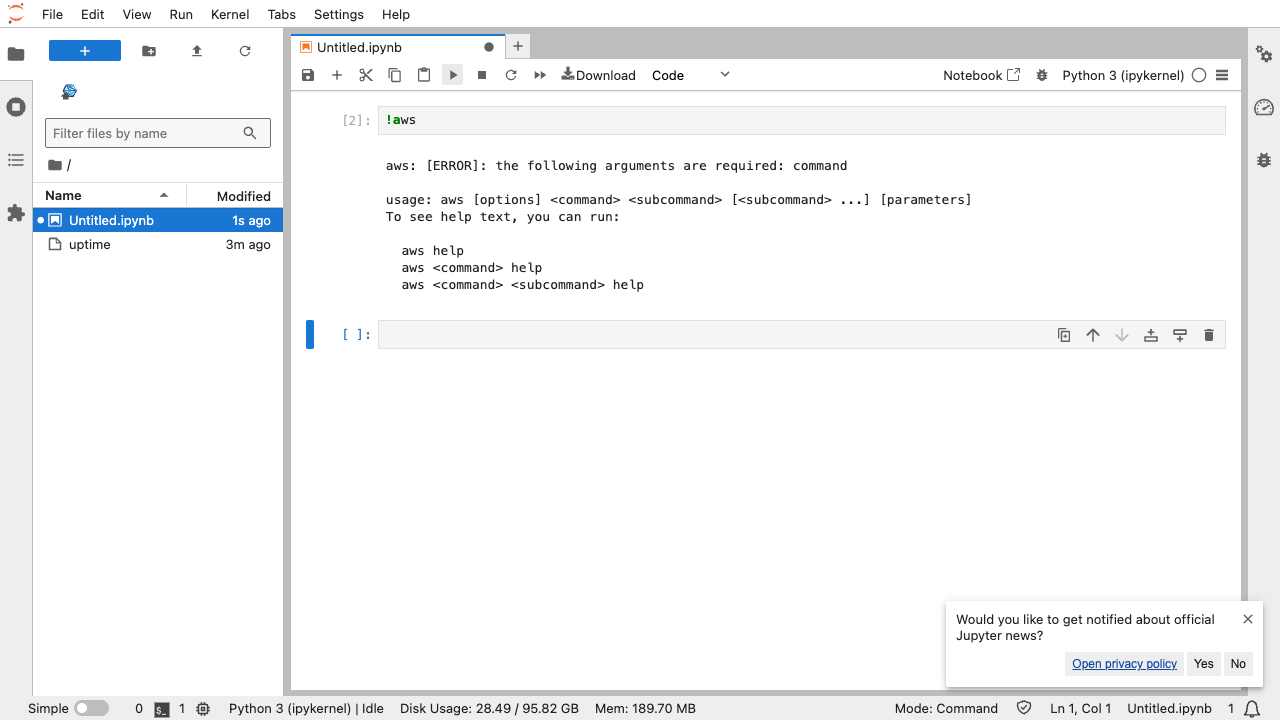

In [106]:
async def _step(page):
    await run_lab_command(page, '!aws', 'usage: aws')

await run_pw(_step)


## 「!papermill」を実行して結果を確認する

コマンドの出力に `Usage: papermill` が含まれること

Start epoch: 1764733466.267471 seconds


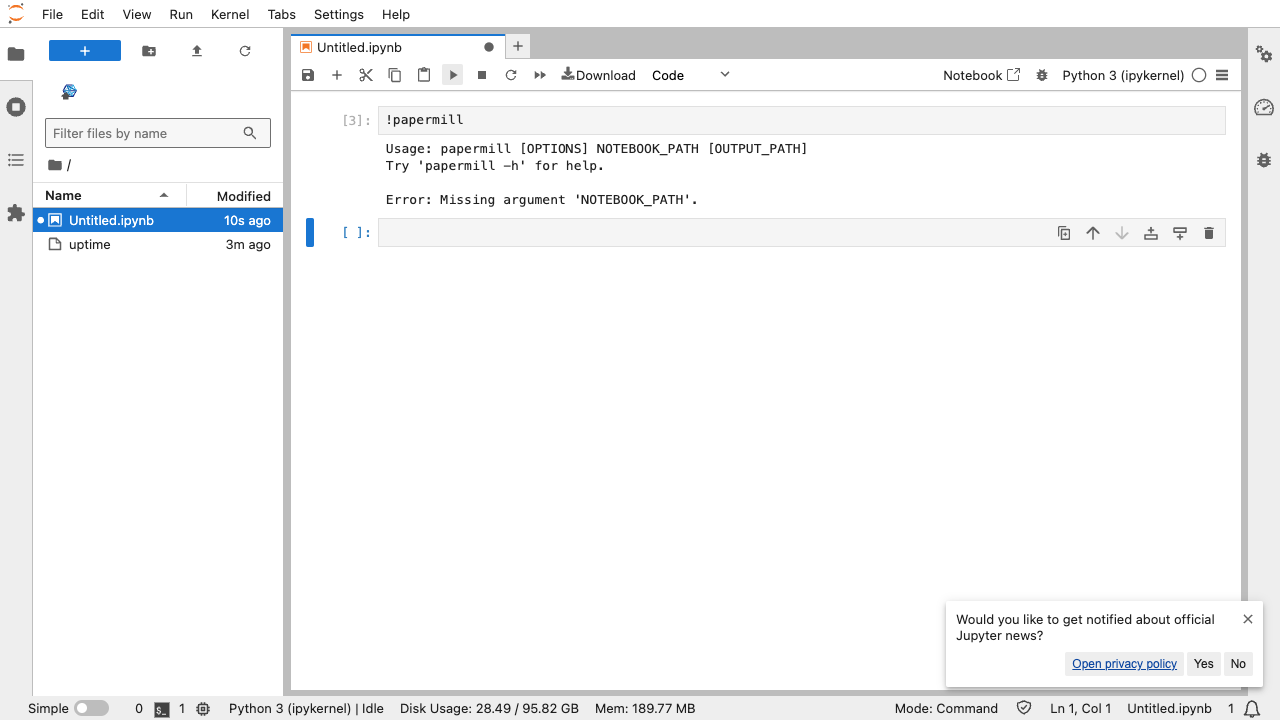

In [107]:
async def _step(page):
    await run_lab_command(page, '!papermill', 'Usage: papermill')

await run_pw(_step)


## Notebookを閉じる

Start epoch: 1764733856.882321 seconds


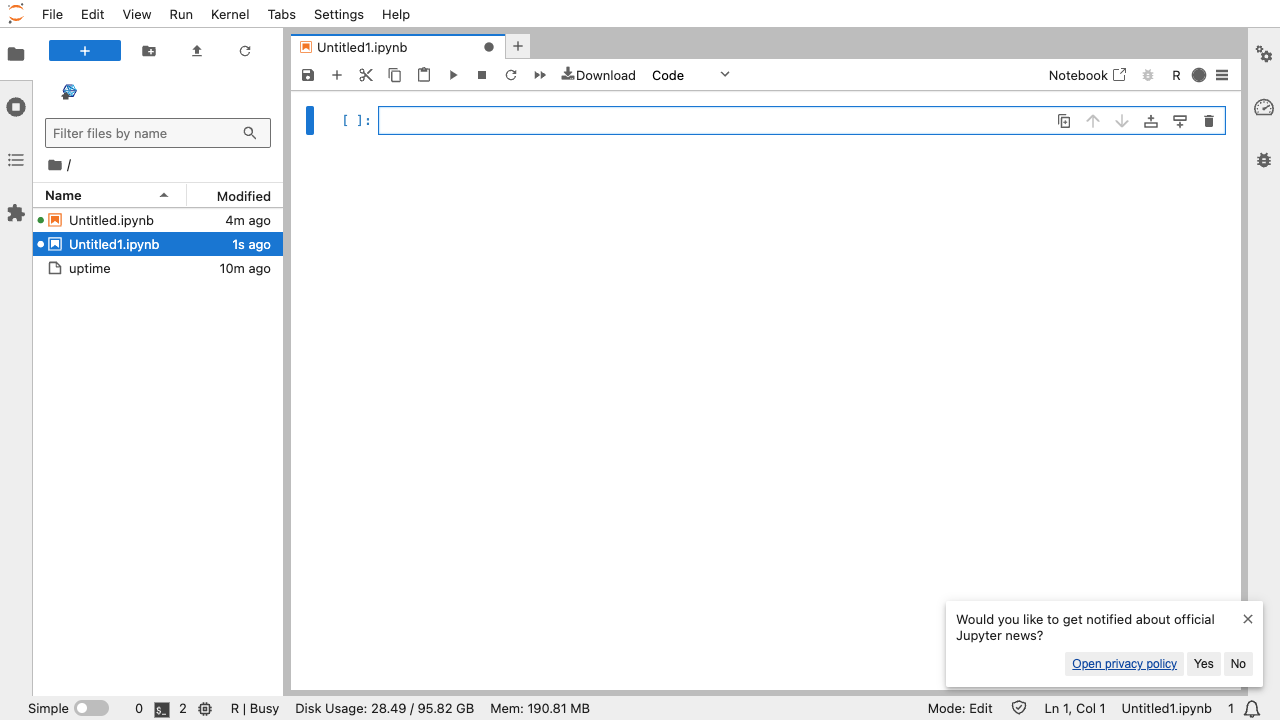

In [ ]:
async def _step(page):
    save_button = page.locator('//jp-button[@data-command = "docmanager:save"]')
    await expect(save_button).to_be_visible(timeout=transition_timeout)
    await save_button.click()

    rename_dialog = page.locator('//div[text() = "Rename"]')
    await expect(rename_dialog).to_be_visible(timeout=transition_timeout)
    await rename_dialog.click()
    await expect(rename_dialog).not_to_be_visible(timeout=transition_timeout)

    close_icon = page.locator('//*[contains(@class, "lm-mod-current")]//*[contains(@class, "lm-TabBar-tabCloseIcon")]')
    await expect(close_icon).to_be_visible(timeout=transition_timeout)
    await close_icon.click()

    launcher_label = 'R'
    launcher = page.locator(f'//*[@class = "jp-LauncherCard" and @title = "{launcher_label}" and @data-category = "Notebook"]')
    await expect(launcher).to_be_visible(timeout=transition_timeout)
    await launcher.click()

    await expect(page.locator('//*[contains(@class, "jp-Notebook-ExecutionIndicator") and @data-status="idle"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「R」ランチャーで `library(eegkit)` を実行する

出力に `TEST` が含まれること

Start epoch: 1764733914.147705 seconds


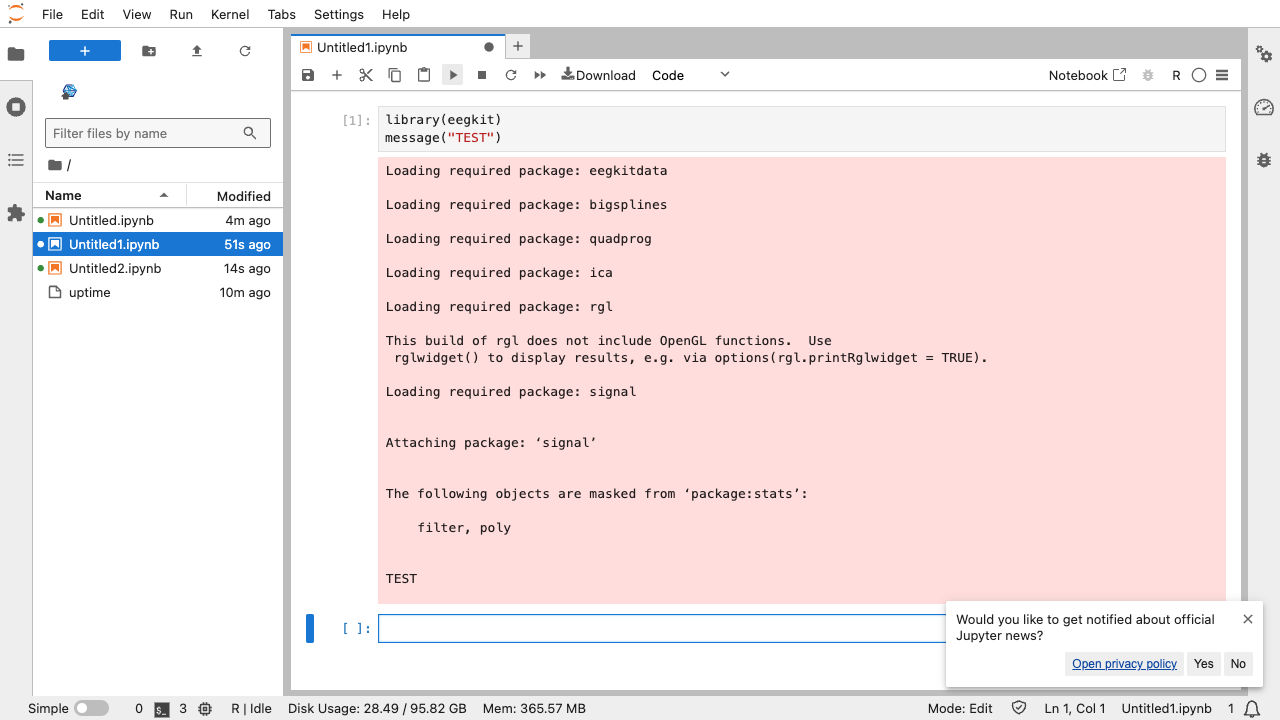

In [112]:
async def _step(page):
    await run_lab_command(page, 'library(eegkit)\nmessage("TEST")', 'TEST')

await run_pw(_step)


## JupyterLabウィンドウを閉じる

TLJHページに戻ること

Start epoch: 1764733928.595733 seconds


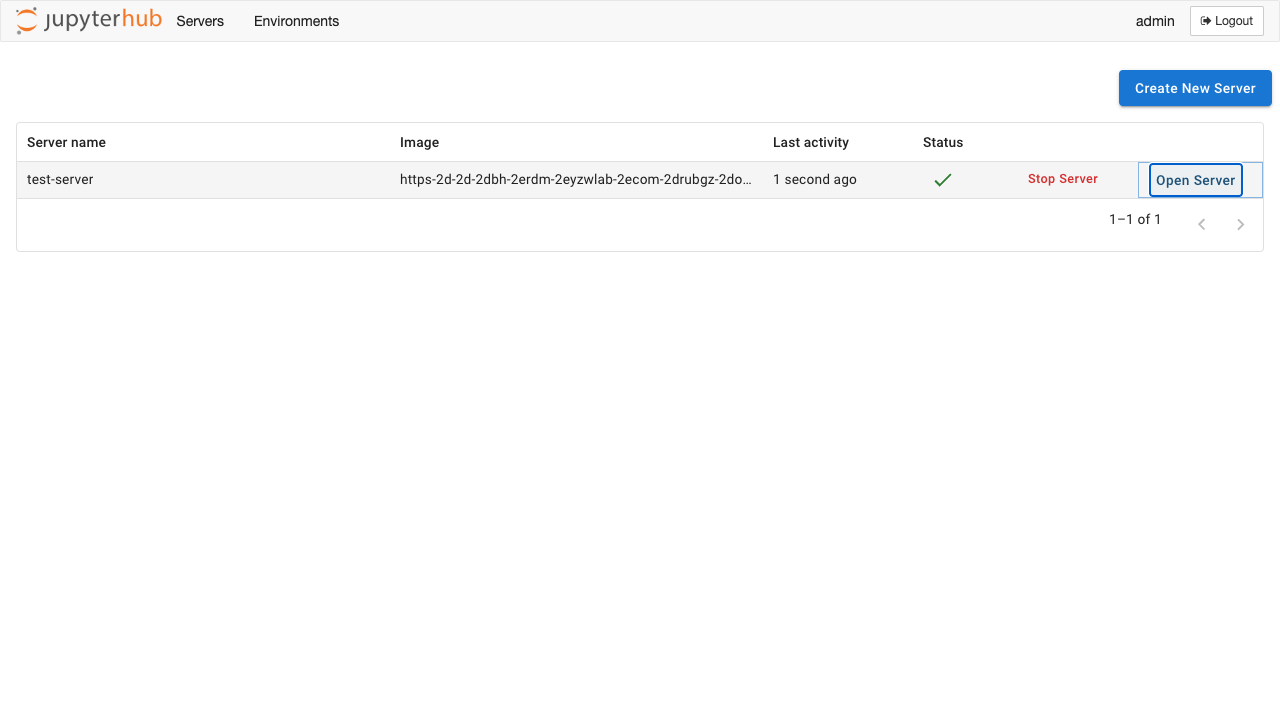

In [113]:
await close_latest_page()

async def _step(page):
    pass

await run_pw(_step)


## 「Stop Server」をクリックし、「Accept」をクリックする

Start epoch: 1764734351.127636 seconds


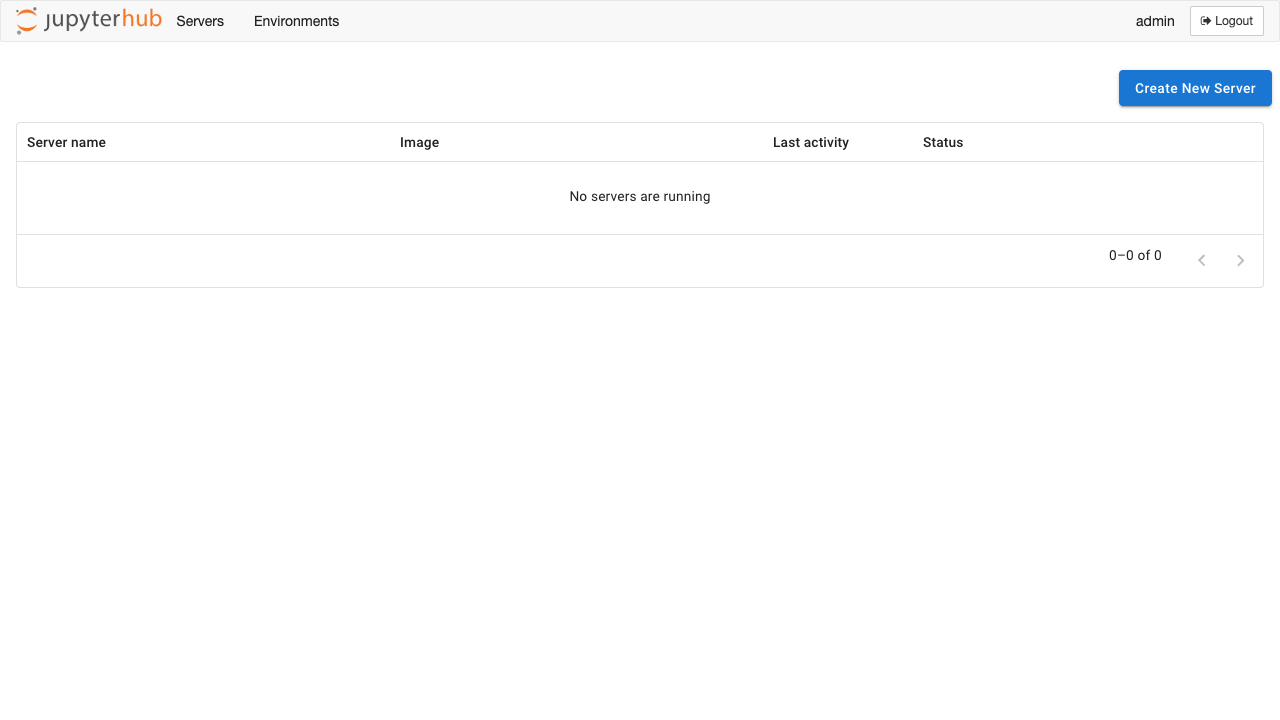

In [114]:
async def _step(page):
    await page.locator('//*[contains(text(), "Stop Server")]').click()
    await page.locator('//*[contains(text(), "Accept")]').click()
    await expect(page.locator('//a[contains(text(), "Open Server")]')).not_to_be_visible(timeout=transition_timeout)

await run_pw(_step)


## TLJHのブラウザタブを閉じ、GRDMの解析ページに戻る

Start epoch: 1764734380.623504 seconds


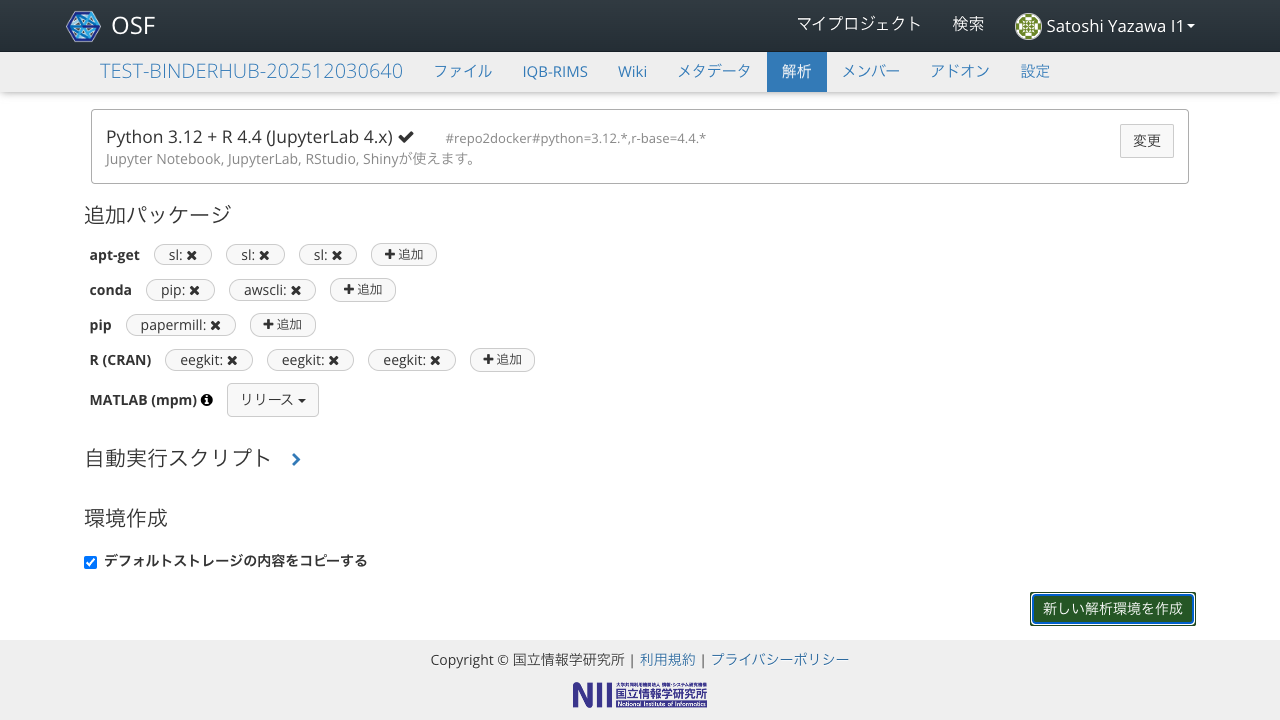

In [115]:
await close_latest_page()

async def _step(page):
    pass

await run_pw(_step)

終了処理を実施する。

In [ ]:
await finish_pw_context()

In [ ]:
!rm -fr {work_dir}